In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/raw/earthquake_data_tsunami.csv')

print("Shape originale:", df.shape)
print(df.head())

Shape originale: (782, 13)
   magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   
2        7.0    3    3  755  147  3.125  18.0  579.000  -20.0508   -178.346   
3        7.3    5    5  833  149  1.865  21.0   37.000  -19.2918   -172.129   
4        6.6    0    2  670  131  4.998  27.0  624.464  -25.5948    178.278   

   Year  Month  tsunami  
0  2022     11        1  
1  2022     11        0  
2  2022     11        1  
3  2022     11        1  
4  2022     11        1  


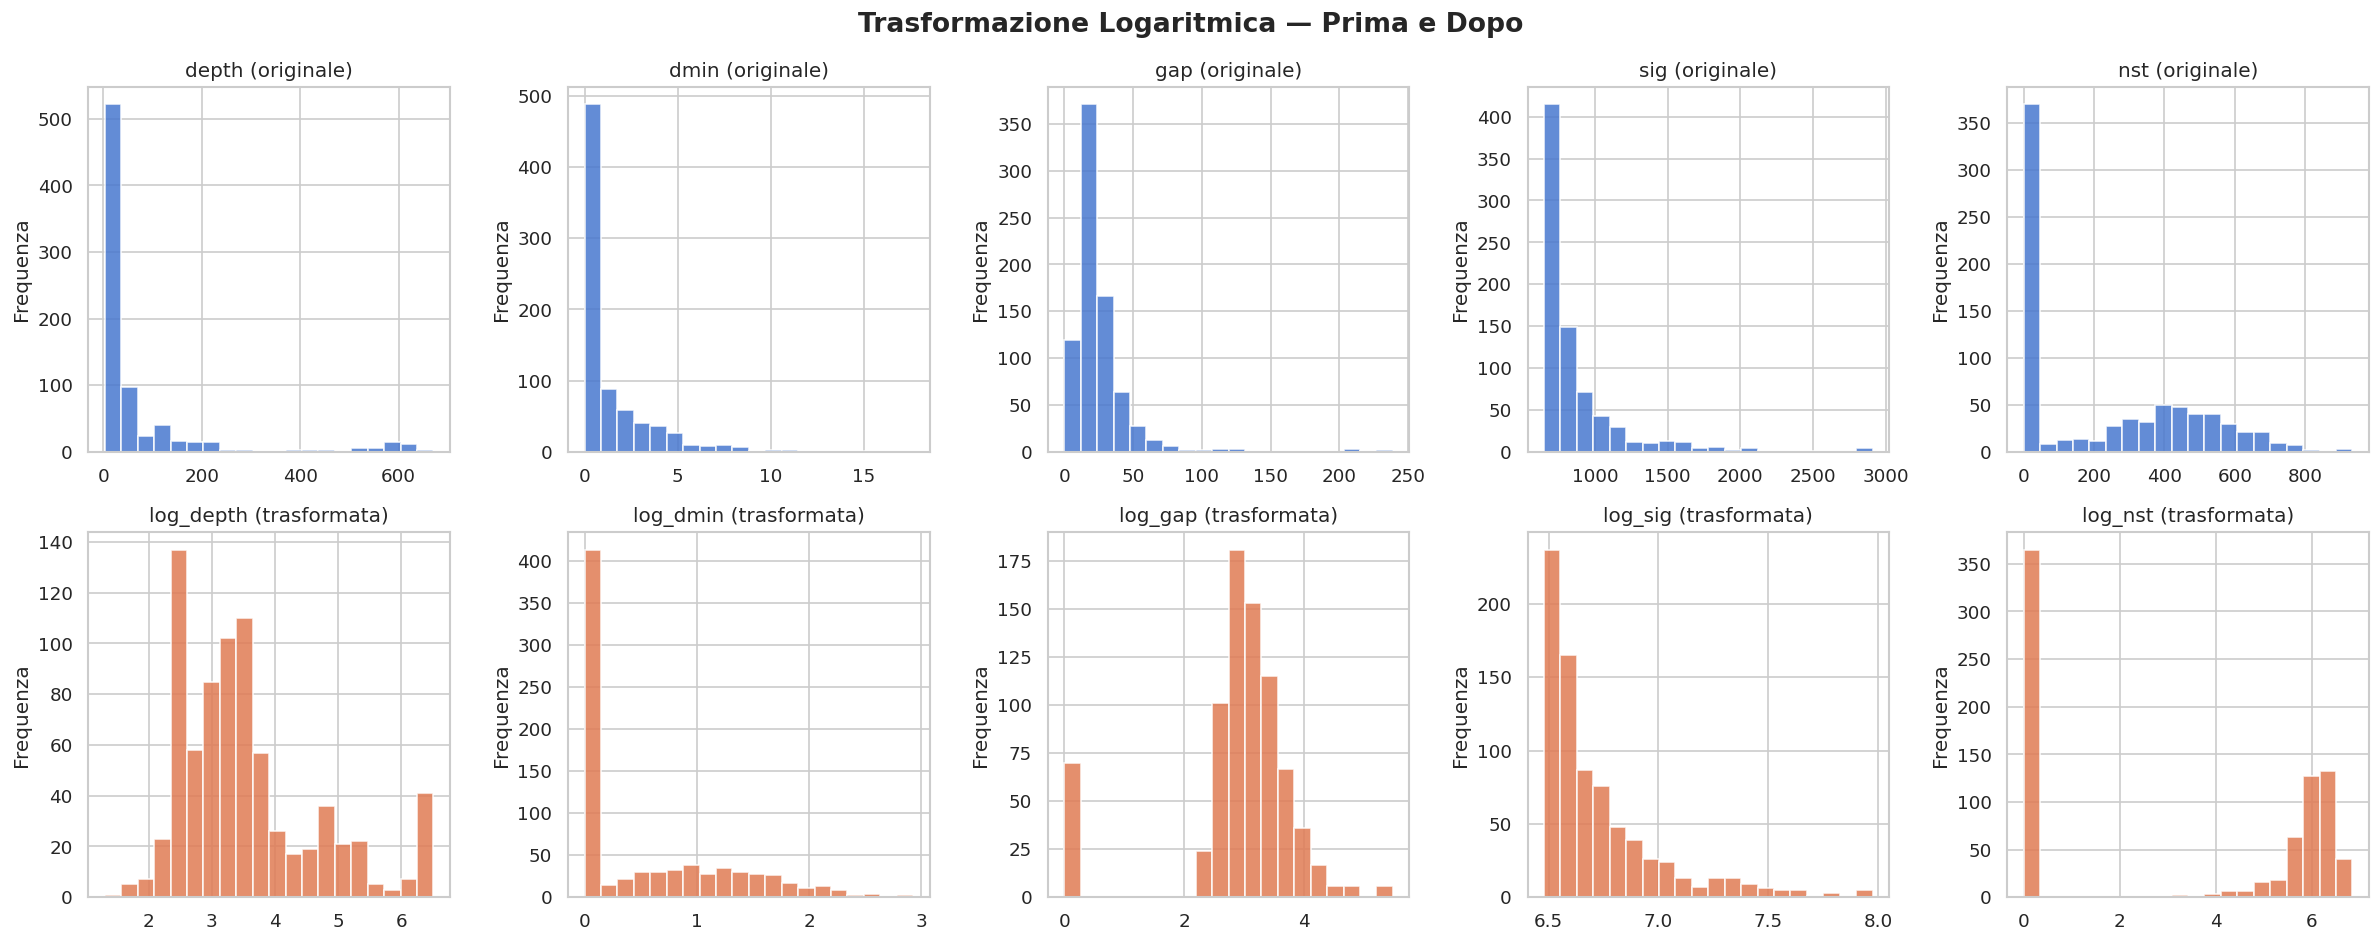

In [3]:

df['log_depth'] = np.log1p(df['depth'])
df['log_dmin']  = np.log1p(df['dmin'])
df['log_gap']   = np.log1p(df['gap'])
df['log_sig']   = np.log1p(df['sig'])
df['log_nst']   = np.log1p(df['nst'])

# confronto prima e dopo
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Trasformazione Logaritmica — Prima e Dopo', fontsize=16, fontweight='bold')

features_log = ['depth', 'dmin', 'gap', 'sig', 'nst']

for i, col in enumerate(features_log):
    axes[0][i].hist(df[col], bins=20, color='#4878CF', edgecolor='white', alpha=0.85)
    axes[0][i].set_title(f'{col} (originale)')
    axes[0][i].set_ylabel('Frequenza')

    axes[1][i].hist(df[f'log_{col}'], bins=20, color='#E07B54', edgecolor='white', alpha=0.85)
    axes[1][i].set_title(f'log_{col} (trasformata)')
    axes[1][i].set_ylabel('Frequenza')

plt.tight_layout()
plt.show()


La trasformazione `log1p` (log(x+1)) è stata applicata alle feature con 
skewness alta e outlier significativi. Il risultato è visibile nei grafici.

### Risultati per feature

- **depth** → distribuzione molto più distribuita, da fortemente skewed 
  a quasi bimodale. Range compresso da [0-650] a [2-6.5]

- **dmin** → miglioramento significativo, distribuzione più uniforme. 
  Range compresso da [0-17] a [0-3]

- **gap** → ottimo risultato, distribuzione quasi simmetrica. 
  Range compresso da [0-250] a [0-5]

- **sig** → distribuzione più uniforme ma ancora con picco iniziale. 
  Range compresso da [700-3000] a [6.5-8]

- **nst** → ancora presente bimodalità con coda a destra. 
  Range compresso da [0-850] a [0-6.5]

### 2. Nuove feature

In [4]:


# distanza dall'equatore
df['dist_equatore'] = df['latitude'].abs()

# terremoto superficiale ad alta magnitudo
df['mag_over_depth'] = df['magnitude'] / (df['depth'] + 1)

# zona Pacifico (Ring of Fire)
df['pacifico'] = ((df['longitude'] > 100) | (df['longitude'] < -60)).astype(int)

# intensità percepita binaria (da distribuzione bimodale cdi)
df['cdi_percepito'] = (df['cdi'] > 2).astype(int)

print("Nuove feature aggiunte:")
print(df[['dist_equatore', 'mag_over_depth', 'pacifico', 'cdi_percepito']].head())

Nuove feature aggiunte:
   dist_equatore  mag_over_depth  pacifico  cdi_percepito
0         9.7963        0.466667         1              1
1         4.9559        0.265385         1              1
2        20.0508        0.012069         1              1
3        19.2918        0.192105         1              1
4        25.5948        0.010552         1              0


## 2. Nuove Feature

Sono state create 4 nuove feature basate sulle osservazioni dell'EDA.

### `dist_equatore`
```python
df['dist_equatore'] = df['latitude'].abs()
```
I terremoti che generano tsunami avvengono spesso in zone di subduzione 
lontane dall'equatore. Cattura l'informazione geografica in modo più 
diretto della latitudine grezza.

### `mag_over_depth`
```python
df['mag_over_depth'] = df['magnitude'] / (df['depth'] + 1)
```
Un terremoto superficiale ad alta magnitudo è più pericoloso di uno profondo 
della stessa magnitudo. Questa feature cattura quella combinazione — 
valore alto = terremoto forte e superficiale.

### `pacifico`
```python
df['pacifico'] = ((df['longitude'] > 100) | (df['longitude'] < -60)).astype(int)
```
Il 90% dei terremoti avviene nel Ring of Fire. Questa feature binaria 
segnala al modello se il terremoto è in quella zona.

### `cdi_percepito`
```python
df['cdi_percepito'] = (df['cdi'] > 2).astype(int)
```
Dalla distribuzione bimodale di `cdi` osservata nell'EDA emergono due 
gruppi distinti — terremoti non percepiti (cdi = 0) e percepiti (cdi > 2). 
Questa feature cattura quella separazione.

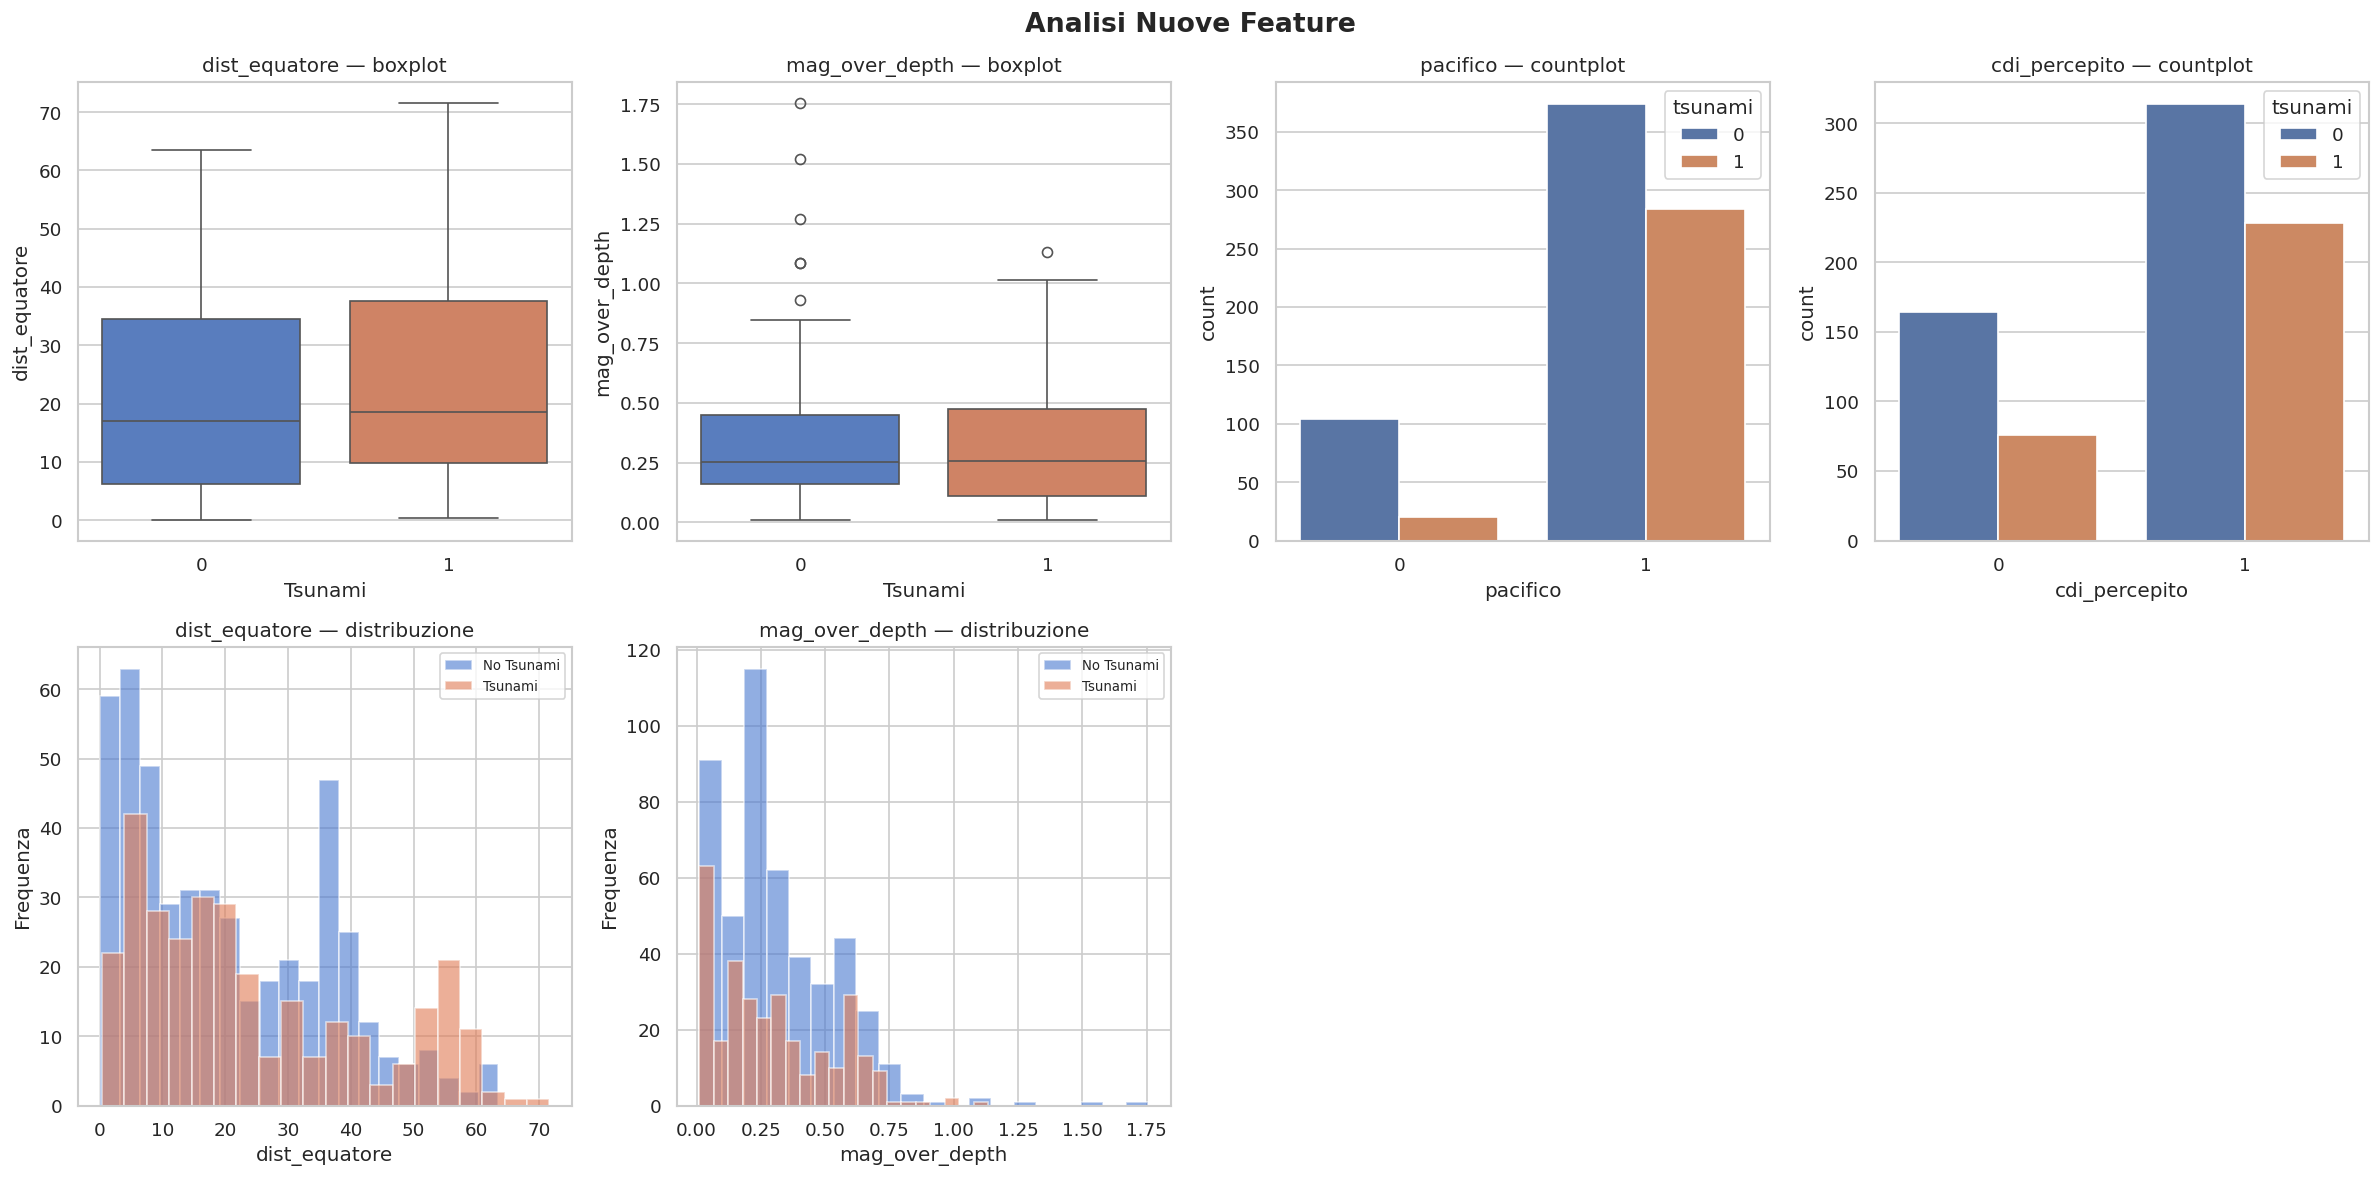

In [5]:
nuove_feature = ['dist_equatore', 'mag_over_depth', 'pacifico', 'cdi_percepito']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Analisi Nuove Feature', fontsize=16, fontweight='bold')

for i, col in enumerate(nuove_feature):

    # riga 1
    if col not in ['pacifico', 'cdi_percepito']:
        sns.boxplot(x='tsunami', y=col, data=df,
                    hue='tsunami',
                    palette={0: '#4878CF', 1: '#E07B54'},
                    legend=False,
                    ax=axes[0][i])
        axes[0][i].set_title(f'{col} — boxplot')
        axes[0][i].set_xlabel('Tsunami')
        axes[0][i].set_ylabel(col)
    else:
        sns.countplot(x=col, hue='tsunami', data=df,
                      ax=axes[0][i])
        axes[0][i].set_title(f'{col} — countplot')
        axes[0][i].set_xlabel(col)

    # riga 2
    if col not in ['pacifico', 'cdi_percepito']:
        df[df['tsunami'] == 0][col].hist(
            bins=20, ax=axes[1][i], color='#4878CF',
            alpha=0.6, label='No Tsunami', edgecolor='white')
        df[df['tsunami'] == 1][col].hist(
            bins=20, ax=axes[1][i], color='#E07B54',
            alpha=0.6, label='Tsunami', edgecolor='white')
        axes[1][i].set_title(f'{col} — distribuzione')
        axes[1][i].set_xlabel(col)
        axes[1][i].set_ylabel('Frequenza')
        axes[1][i].legend(fontsize=8)
    else:
        axes[1][i].set_visible(False)

plt.tight_layout()
plt.show()


### `dist_equatore`
- I boxplot mostrano distribuzioni molto simili tra le due classi
- La mediana è quasi identica (~20°) per tsunami e no tsunami
- La distribuzione si sovrappone molto — la feature da sola 
  non discrimina bene le classi
- Utile come feature geografica di supporto

### `mag_over_depth`
- Boxplot quasi identici tra tsunami=0 e tsunami=1
- Le distribuzioni si sovrappongono completamente
- Entrambe le classi concentrate tra 0 e 0.5
- Feature poco discriminante — valutare rimozione

### `pacifico`
- La feature più informativa tra le nuove
- Quasi tutti i tsunami (arancione) avvengono nel Pacifico (pacifico=1)
- I no-tsunami si distribuiscono più equamente tra Pacifico e non
- Chiara separazione tra le classi

### `cdi_percepito`
- I tsunami tendono ad avvenire quando il terremoto è 
  percepito dalla popolazione (cdi_percepito=1)
- I no-tsunami si distribuiscono più uniformemente tra 0 e 1
- Separazione visibile ma non netta  


vISTO QUESTO POSSIAMO TOGLIERE dist_equatore

In [6]:
import os
os.makedirs('../data/processed', exist_ok=True)

feature_finali = [
    'magnitude', 'cdi', 'mmi',
    'log_depth', 'log_sig', 'log_dmin', 'log_gap', 'log_nst',
    'latitude', 'longitude', 'dist_equatore', 'pacifico',
    'cdi_percepito', 'tsunami'
]

# salva dataset SENZA scaling
df_final = df[feature_finali].copy()
df_final.to_csv('../data/processed/earthquake_processed.csv', index=False)

print("Dataset salvato in data/processed/earthquake_processed.csv")
print("Shape:", df_final.shape)
print("\nFeature:", df_final.columns.tolist())
print("\nPrime righe:")
print(df_final.head())

Dataset salvato in data/processed/earthquake_processed.csv
Shape: (782, 14)

Feature: ['magnitude', 'cdi', 'mmi', 'log_depth', 'log_sig', 'log_dmin', 'log_gap', 'log_nst', 'latitude', 'longitude', 'dist_equatore', 'pacifico', 'cdi_percepito', 'tsunami']

Prime righe:
   magnitude  cdi  mmi  log_depth   log_sig  log_dmin   log_gap   log_nst  \
0        7.0    8    7   2.708050  6.645091  0.411447  2.890372  4.770685   
1        6.9    4    4   3.258097  6.601230  1.172172  3.555348  4.605170   
2        7.0    3    3   6.363028  6.628041  1.417066  2.944439  4.997212   
3        7.3    5    5   3.637586  6.726233  1.052568  3.091042  5.010635   
4        6.6    0    2   6.438494  6.508769  1.791426  3.332205  4.882802   

   latitude  longitude  dist_equatore  pacifico  cdi_percepito  tsunami  
0   -9.7963    159.596         9.7963         1              1        1  
1   -4.9559    100.738         4.9559         1              1        0  
2  -20.0508   -178.346        20.0508         1